# EDA: Flow-Based Gentrification in London
**Dissertation Meeting 1 — Option C: Fixed Baseline + IMD-Change Validation**

### Methodology
- **Cascading Flow Index**: Uses **IMD 2010** (fixed baseline) to assign wealth deciles to
  MSOAs, then measures cascade flows from the **2021 Census O-D** data.
- **Temporal Validation**: Independently compute IMD change (2010 → 2019) per MSOA.
  If the cascade index correctly identifies gentrifying areas, those MSOAs
  should also show declining deprivation over the preceding decade.
- **Geography**: All analysis harmonised to **2011 MSOA codes** using the ONS
  MSOA 2011-to-2021 lookup. MSOAs that were split/merged are excluded.

### Note on 2011 Census Data
MSOA-level residential migration O-D data from the 2011 Census is classified as safeguarded and not publicly available. 
The publicly available migration tables (MM01C) are only at Local Authority level. 
If WICID access is obtained later, a direct 2011-vs-2021 flow comparison can be added.

---

### Contents
1. Data loading & overview
2. Geography harmonisation (2021 → 2011 MSOA codes)
3. London filter & IMD aggregation (both 2010 and 2019)
4. Wealth decile assignment (fixed 2010 baseline)
5. IMD change analysis (temporal dimension)
6. Origin–Destination flow heatmap (2021)
7. Cascading displacement signal
8. Per-MSOA cascade features
9. Validation: cascade index vs IMD change
10. Borough-level summary
11. Export

In [38]:
# %pip install xlrd

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pyprojroot import here
from scipy import stats


sns.set_theme(style='whitegrid', font_scale=1.1)

ROOT = here()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

---
## 1. Load All Datasets

| File | Description |
|------|-------------|
| `ODMG01EW_MSOA.csv` | 2021 Census migration O-D (MSOA level) |
| `imd_2019.csv` | IMD 2019 at LSOA level |
| `imd_2010.csv` | IMD 2010 at LSOA level |
| `NSPCL_NOV22_UK_LU.csv` | Postcode lookup (2011 geographies) |
| `msoa_2011_to_2021_lookup.csv` | MSOA 2011 ↔ 2021 code mapping |

In [40]:
# ---- File paths (adjust if needed) ----
imd_2010_path       = DATA_DIR / 'imd_2010.xls'
imd_2019_path       = DATA_DIR / 'imd_2019.csv'
census_od_2021_path = DATA_DIR / 'ODMG01EW_MSOA.csv'
lookup_path         = DATA_DIR / 'NSPCL_NOV22_UK_LU.csv'
msoa_lookup_path    = DATA_DIR / 'msoa_2011_to_2021_lookup.csv'

In [41]:
# ---- Load IMD ----
imd_2019 = pd.read_csv(imd_2019_path)
imd_2019.columns = imd_2019.columns.str.strip()

imd_2010 = pd.read_excel(imd_2010_path, sheet_name='IMD 2010')
imd_2010.columns = imd_2010.columns.str.strip()

# ---- Load Census O-D ----
census_od_2021 = pd.read_csv(census_od_2021_path)

# ---- Load Lookups ----
lookup = pd.read_csv(lookup_path, encoding='ISO-8859-1', low_memory=False)
msoa_11_21 = pd.read_csv(msoa_lookup_path)

# Quick overview
for name, df in [('IMD 2010', imd_2010), ('IMD 2019', imd_2019),
                  ('Census O-D 2021', census_od_2021), ('MSOA Lookup', msoa_11_21)]:
    print(f'\n===== {name} =====')
    print(f'Shape: {df.shape}')
    print(f'Columns: {df.columns.tolist()}')
    display(df.head(2))


===== IMD 2010 =====
Shape: (32482, 7)
Columns: ['LSOA CODE', 'LA CODE', 'LA NAME', 'GOR CODE', 'GOR NAME', 'IMD SCORE', 'RANK OF IMD SCORE (where 1 is most deprived)']


,LSOA CODE,LA CODE,LA NAME,GOR CODE,GOR NAME,IMD SCORE,RANK OF IMD SCORE (where 1 is most deprived)
0,E01000001,00AA,City of London,H,London,6.161637,28814
1,E01000002,00AA,City of London,H,London,5.585054,29450



===== IMD 2019 =====
Shape: (32844, 57)
Columns: ['LSOA code (2011)', 'LSOA name (2011)', 'Local Authority District code (2019)', 'Local Authority District name (2019)', 'Index of Multiple Deprivation (IMD) Score', 'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Score (rate)', 'Income Rank (where 1 is most deprived)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employment Score (rate)', 'Employment Rank (where 1 is most deprived)', 'Employment Decile (where 1 is most deprived 10% of LSOAs)', 'Education, Skills and Training Score', 'Education, Skills and Training Rank (where 1 is most deprived)', 'Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)', 'Health Deprivation and Disability Score', 'Health Deprivation and Disability Rank (where 1 is most deprived)', 'Health Deprivation and Disability Decile (where 1 is most deprived 10% 

,LSOA code (2011),LSOA name (2011),Local Authority District code (2019),Local Authority District name (2019),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),...,Indoors Sub-domain Rank (where 1 is most deprived),Indoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Outdoors Sub-domain Score,Outdoors Sub-domain Rank (where 1 is most deprived),Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2015 (excluding prisoners),Dependent Children aged 0-15: mid 2015 (excluding prisoners),Population aged 16-59: mid 2015 (excluding prisoners),Older population aged 60 and over: mid 2015 (excluding prisoners),Working age population 18-59/64: for use with Employment Deprivation Domain (excluding prisoners)
0,E01000001,City of London 001A,E09000001,City of London,6.208,29199,9,0.007,32831,10,...,16364,5,1.503,1615,1,1296,175,656,465,715
1,E01000002,City of London 001B,E09000001,City of London,5.143,30379,10,0.034,29901,10,...,22676,7,1.196,2969,1,1156,182,580,394,620



===== Census O-D 2021 =====
Shape: (1490726, 5)
Columns: ['Migrant MSOA one year ago code', 'Migrant MSOA one year ago label', 'Middle layer Super Output Areas code', 'Middle layer Super Output Areas label', 'Count']


,Migrant MSOA one year ago code,Migrant MSOA one year ago label,Middle layer Super Output Areas code,Middle layer Super Output Areas label,Count
0,-8,Does not apply,E02000001,City of London 001,6237
1,-8,Does not apply,E02000002,Barking and Dagenham 001,7622



===== MSOA Lookup =====
Shape: (7201, 9)
Columns: ['MSOA11CD', 'MSOA11NM', 'CHNGIND', 'MSOA21CD', 'MSOA21NM', 'LAD22CD', 'LAD22NM', 'LAD22NMW', 'ObjectId']


,MSOA11CD,MSOA11NM,CHNGIND,MSOA21CD,MSOA21NM,LAD22CD,LAD22NM,LAD22NMW,ObjectId
0,E02000001,City of London 001,NaN,E02000001,City of London 001,E09000001,City of London,NaN,1
1,E02000002,Barking and Dagenham 001,NaN,E02000002,Barking and Dagenham 001,E09000002,Barking and Dagenham,NaN,2


---
## 2. Geography Harmonisation: 2021 MSOA Codes → 2011

The 2021 census uses 2021 MSOA codes, but IMD and our lookup use 2011 codes.
Most MSOAs are unchanged (~97.5%). We keep only those with a clean 1:1 mapping.

In [42]:
msoa_11_21.columns = msoa_11_21.columns.str.strip().str.lower()
print('MSOA lookup columns:', msoa_11_21.columns.tolist())
print('\nChange indicator counts:')
print(msoa_11_21['chngind'].value_counts())

MSOA lookup columns: ['msoa11cd', 'msoa11nm', 'chngind', 'msoa21cd', 'msoa21nm', 'lad22cd', 'lad22nm', 'lad22nmw', 'objectid']

Change indicator counts:
Series([], Name: count, dtype: int64)


In [43]:
# Replace the chgind filter with:
unchanged = msoa_11_21[msoa_11_21['msoa11cd'] == msoa_11_21['msoa21cd']].copy()
msoa21_to_11 = dict(zip(unchanged['msoa21cd'], unchanged['msoa11cd']))

print(f'Total MSOAs in lookup: {len(msoa_11_21)}')
print(f'Unchanged (usable):    {len(unchanged)}')
print(f'Dropped (split/merged): {len(msoa_11_21) - len(unchanged)}')

Total MSOAs in lookup: 7201
Unchanged (usable):    7080
Dropped (split/merged): 121


In [44]:
# Convert 2021 O-D data to 2011 MSOA codes
ORIGIN_COL = 'Migrant MSOA one year ago code'
DEST_COL   = 'Middle layer Super Output Areas code'

census_od_2021['origin_msoa11'] = census_od_2021[ORIGIN_COL].map(msoa21_to_11)
census_od_2021['dest_msoa11']   = census_od_2021[DEST_COL].map(msoa21_to_11)

n_total = len(census_od_2021)
n_mapped = census_od_2021[['origin_msoa11', 'dest_msoa11']].notna().all(axis=1).sum()
print(f'2021 O-D records: {n_total:,}')
print(f'Both endpoints mapped to 2011 codes: {n_mapped:,} ({n_mapped/n_total*100:.1f}%)')

2021 O-D records: 1,490,726
Both endpoints mapped to 2011 codes: 1,349,030 (90.5%)


---
## 3. London Filter & IMD Aggregation to MSOA

In [45]:
london_boroughs = [
    'City of London', 'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent',
    'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich',
    'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering',
    'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea',
    'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham',
    'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton',
    'Tower Hamlets', 'Waltham Forest', 'Wandsworth', 'Westminster'
]

london_lookup = (
    lookup[lookup['ladnm'].isin(london_boroughs)]
    [['lsoa11cd', 'msoa11cd', 'ladnm']]
    .drop_duplicates()
)

print(f'London LSOAs: {london_lookup["lsoa11cd"].nunique()}')
print(f'London MSOAs: {london_lookup["msoa11cd"].nunique()}')
print(f'Boroughs:     {london_lookup["ladnm"].nunique()}')

London LSOAs: 4835
London MSOAs: 983
Boroughs:     33


In [46]:
# ---- IMD 2010 → MSOA ----
# IMPORTANT: Adjust these column names to match your IMD 2010 file
IMD_2010_LSOA_COL  = 'LSOA CODE'   # <-- check your file
IMD_2010_SCORE_COL = 'IMD SCORE'    # <-- check your file

imd_2010_london = pd.merge(
    imd_2010[[IMD_2010_LSOA_COL, IMD_2010_SCORE_COL]],
    london_lookup,
    left_on=IMD_2010_LSOA_COL, right_on='lsoa11cd'
)
msoa_imd_2010 = (
    imd_2010_london
    .groupby(['msoa11cd', 'ladnm'])[IMD_2010_SCORE_COL]
    .mean().reset_index()
    .rename(columns={IMD_2010_SCORE_COL: 'IMD_2010'})
)

# ---- IMD 2019 → MSOA ----
imd_2019_london = pd.merge(
    imd_2019[['LSOA code (2011)', 'Index of Multiple Deprivation (IMD) Score']],
    london_lookup,
    left_on='LSOA code (2011)', right_on='lsoa11cd'
)
msoa_imd_2019 = (
    imd_2019_london
    .groupby('msoa11cd')['Index of Multiple Deprivation (IMD) Score']
    .mean().reset_index()
    .rename(columns={'Index of Multiple Deprivation (IMD) Score': 'IMD_2019'})
)

# ---- Combine ----
msoa_wealth = pd.merge(msoa_imd_2010, msoa_imd_2019, on='msoa11cd', how='inner')
msoa_wealth['IMD_Change'] = msoa_wealth['IMD_2019'] - msoa_wealth['IMD_2010']

print(f'London MSOAs with both IMD years: {len(msoa_wealth)}')
msoa_wealth.head()

London MSOAs with both IMD years: 983


,msoa11cd,ladnm,IMD_2010,IMD_2019,IMD_Change
0,E02000001,City of London,11.601068,14.805000,3.203932
1,E02000002,Barking and Dagenham,42.878192,34.585750,-8.292442
2,E02000003,Barking and Dagenham,25.410160,24.880833,-0.529327
3,E02000004,Barking and Dagenham,22.733532,23.954250,1.220718
4,E02000005,Barking and Dagenham,32.804146,30.928600,-1.875546


---
## 4. Wealth Deciles (Fixed 2010 Baseline)

Deciles are assigned using **IMD 2010 only**, so the classification is
identical regardless of which census year we analyse.

Average number of MSOAs per decile: 98.3


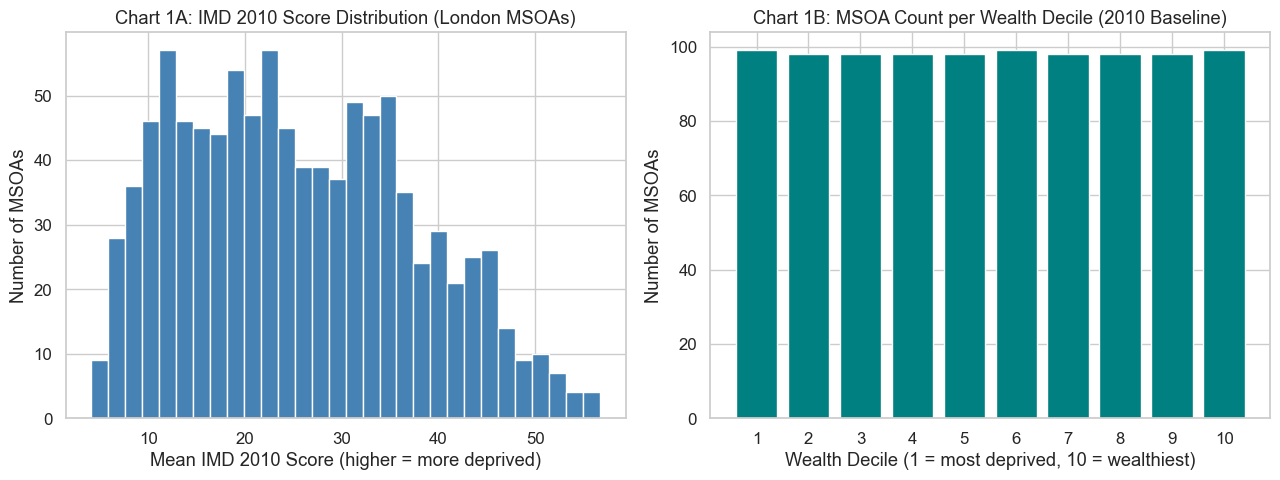

In [47]:
msoa_wealth['Wealth_Decile'] = pd.qcut(
    msoa_wealth['IMD_2010'], 10, labels=False
) + 1
msoa_wealth['Wealth_Decile'] = 11 - msoa_wealth['Wealth_Decile']
# 1 = most deprived, 10 = least deprived (wealthiest)

wealth_dict = msoa_wealth.set_index('msoa11cd')['Wealth_Decile'].to_dict()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(msoa_wealth['IMD_2010'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Mean IMD 2010 Score (higher = more deprived)')
axes[0].set_ylabel('Number of MSOAs')
axes[0].set_title('Chart 1A: IMD 2010 Score Distribution (London MSOAs)')

decile_counts = msoa_wealth['Wealth_Decile'].value_counts().sort_index()

avg_msoa_count = decile_counts.mean()
print(f"Average number of MSOAs per decile: {avg_msoa_count}")

axes[1].bar(decile_counts.index, decile_counts.values, color='teal', edgecolor='white')
axes[1].set_xlabel('Wealth Decile (1 = most deprived, 10 = wealthiest)')
axes[1].set_ylabel('Number of MSOAs')
axes[1].set_title('Chart 1B: MSOA Count per Wealth Decile (2010 Baseline)')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_imd_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

##### NOTE:

Chart 1A: London's IMD distribution is right-skewed. Most MSOAs have low-to-moderate deprivation, with a long tail of highly deprived areas. 

Chart 1B: The decile chart gives roughly equal counts (~98 MSOAs per decile).

> The number of MSOAs is identical between 2010 and 2019 because both IMD datasets use 2011 LSOA codes, and we aggregate to the same set of 2011 MSOAs. The scores change, but the geography doesn't.

---
## 5. IMD Change Analysis (Temporal Dimension)

Which MSOAs became less deprived between 2010 and 2019?
This serves as our independent validation of gentrification.

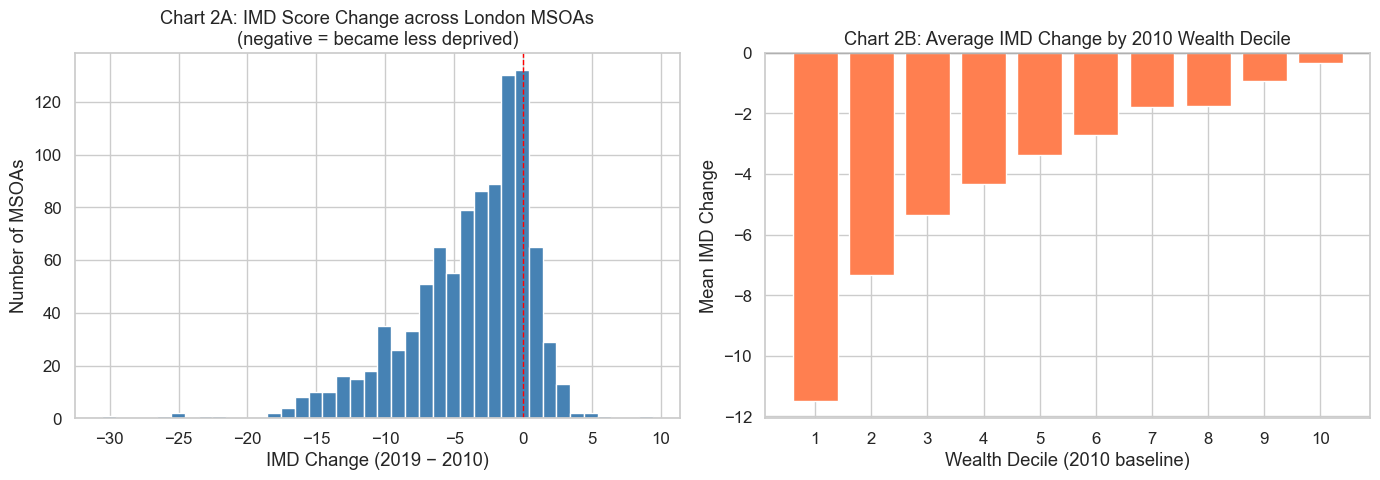

MSOAs that became less deprived: 814 (82.8%)
MSOAs that became more deprived: 169 (17.2%)


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of IMD change
axes[0].hist(msoa_wealth['IMD_Change'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('IMD Change (2019 − 2010)')
axes[0].set_ylabel('Number of MSOAs')
axes[0].set_title('Chart 2A: IMD Score Change across London MSOAs\n(negative = became less deprived)')

# IMD change by baseline decile
decile_change = msoa_wealth.groupby('Wealth_Decile')['IMD_Change'].mean()
colors = ['coral' if v < 0 else 'steelblue' for v in decile_change.values]
axes[1].bar(decile_change.index, decile_change.values, color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Wealth Decile (2010 baseline)')
axes[1].set_ylabel('Mean IMD Change')
axes[1].set_title('Chart 2B: Average IMD Change by 2010 Wealth Decile')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_imd_change.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
n_less_deprived = (msoa_wealth['IMD_Change'] < 0).sum()
n_more_deprived = (msoa_wealth['IMD_Change'] > 0).sum()
total = len(msoa_wealth)
print(f'MSOAs that became less deprived: {n_less_deprived} ({n_less_deprived/total*100:.1f}%)')
print(f'MSOAs that became more deprived: {n_more_deprived} ({n_more_deprived/total*100:.1f}%)')

##### NOTE:

Chart 2A: 814 out of 983 MSOAs (~83%) became less deprived between 2010 and 2019. London as a whole saw widespread deprivation decline.

Chart 2B: the most deprived MSOAs (decile 1) saw the largest IMD drops (~11 points), while the wealthiest (decile 9–10) barely changed. This is consistent with gentrification theory: the poorest areas are changing the fastest. 

But IMD alone can't distinguish between genuine neighbourhood improvement (better services, investment) and demographic displacement (poorer residents pushed out and replaced by wealthier ones).

So, _did the neighbourhood actually improve, or did the poor residents just get replaced by wealthier ones?_

So far, IMD tells us that deprived areas changed, but not how. By analysing who moved in and who moved out, we can test whether this change was driven by cascading displacement (affluent people moving into deprived areas while existing residents moved to even more deprived ones).

---
## 6. Origin–Destination Flow Heatmap (2021)

In [49]:
# Clean O-D data & assign deciles (using harmonised 2011 codes)
od = census_od_2021.copy()
od = od[od[ORIGIN_COL].astype(str) != '-8'].copy()

od['Origin_Decile'] = od['origin_msoa11'].map(wealth_dict)
od['Dest_Decile']   = od['dest_msoa11'].map(wealth_dict)

# Keep only London-to-London flows
london_flow = od.dropna(subset=['Origin_Decile', 'Dest_Decile']).copy()
london_flow['Origin_Decile'] = london_flow['Origin_Decile'].astype(int)
london_flow['Dest_Decile']   = london_flow['Dest_Decile'].astype(int)

# Detect count column
count_cols = [c for c in london_flow.columns if 'observation' in c.lower() or 'count' in c.lower()]
COUNT_COL = count_cols[0] if count_cols else '_count'
if COUNT_COL == '_count':
    london_flow[COUNT_COL] = 1

london_flow['Decile_Shift'] = london_flow['Dest_Decile'] - london_flow['Origin_Decile']

print(f'Total O-D records (raw):     {len(census_od_2021):,}')
print(f'After removing non-migrants: {len(od):,}')
print(f'London-to-London flows:      {len(london_flow):,}')
print(f'Total migrants:              {london_flow[COUNT_COL].sum():,.0f}')
print(f'Count column used:           {COUNT_COL}')

Total O-D records (raw):     1,490,726
After removing non-migrants: 1,483,462
London-to-London flows:      174,274
Total migrants:              766,502
Count column used:           Count


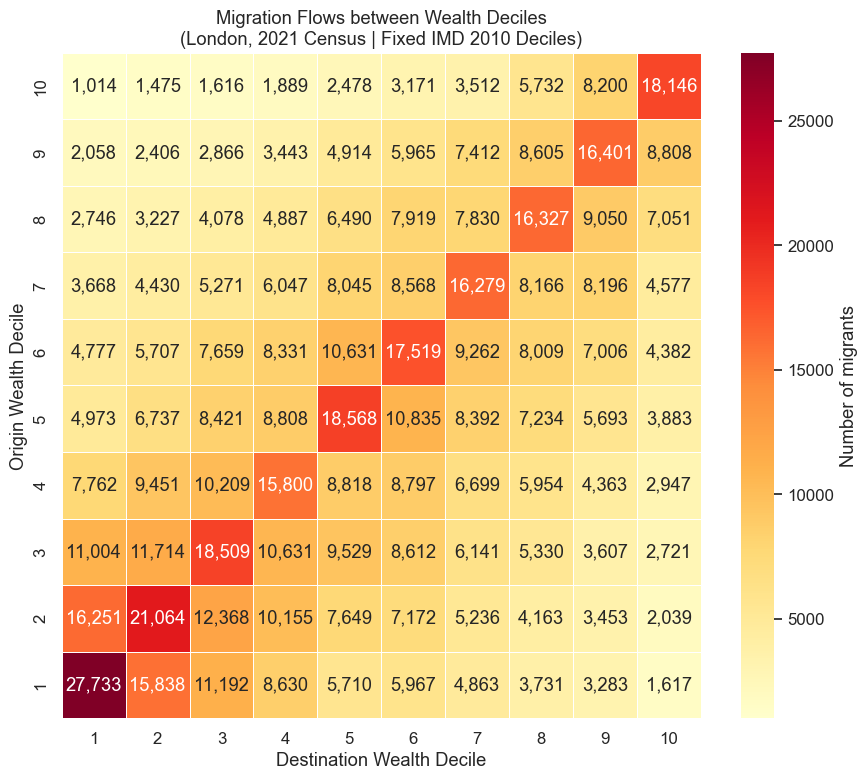

In [50]:
# Flow matrix heatmap
flow_matrix = london_flow.pivot_table(
    index='Origin_Decile', columns='Dest_Decile',
    values=COUNT_COL, aggfunc='sum', fill_value=0
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    flow_matrix, annot=True, fmt=',.0f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Number of migrants'}, ax=ax
)
ax.set_xlabel('Destination Wealth Decile')
ax.set_ylabel('Origin Wealth Decile')
ax.set_title('Migration Flows between Wealth Deciles\n(London, 2021 Census | Fixed IMD 2010 Deciles)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_od_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##### NOTE:

- The largest flows are along the diagonal (same-decile moves), which means people mostly move to areas of similar deprivation.

- The most deprived areas have the highest internal churn (decile 1→1 has 27,733 migrants, _the single largest flow_). Meanwhile flows from deprived origins to wealthy destinations are much smaller (decile 1→10 has 1,617 migrants). 

- People in deprived areas overwhelmingly stay in deprived areas when they move.

> Questions: How to understand the churn from decile 10 to 1? There are surprisingly a certain number of migrants!





---
## 7. Cascading Displacement Signal

In [51]:
# Flow direction summary
total = london_flow[COUNT_COL].sum()
upward   = london_flow[london_flow['Decile_Shift'] > 0][COUNT_COL].sum()
downward = london_flow[london_flow['Decile_Shift'] < 0][COUNT_COL].sum()
lateral  = london_flow[london_flow['Decile_Shift'] == 0][COUNT_COL].sum()

print('=== Flow Direction Summary (2021) ===')
print(f'  Upward (to wealthier):       {upward:>10,.0f}  ({upward/total*100:.1f}%)')
print(f'  Downward (to more deprived): {downward:>10,.0f}  ({downward/total*100:.1f}%)')
print(f'  Lateral (same decile):       {lateral:>10,.0f}  ({lateral/total*100:.1f}%)')
print(f'  Total:                       {total:>10,.0f}')

=== Flow Direction Summary (2021) ===
  Upward (to wealthier):          307,759  (40.2%)
  Downward (to more deprived):    272,397  (35.5%)
  Lateral (same decile):          186,346  (24.3%)
  Total:                          766,502


##### NOTE:

This is the volume of flows:

- 40.2% London migrants move to a wealthier area, while 35.5% move to a more deprived one.
    - This looks like net upward mobility.

- We need to focus more on the 272,397 downward migrants. 

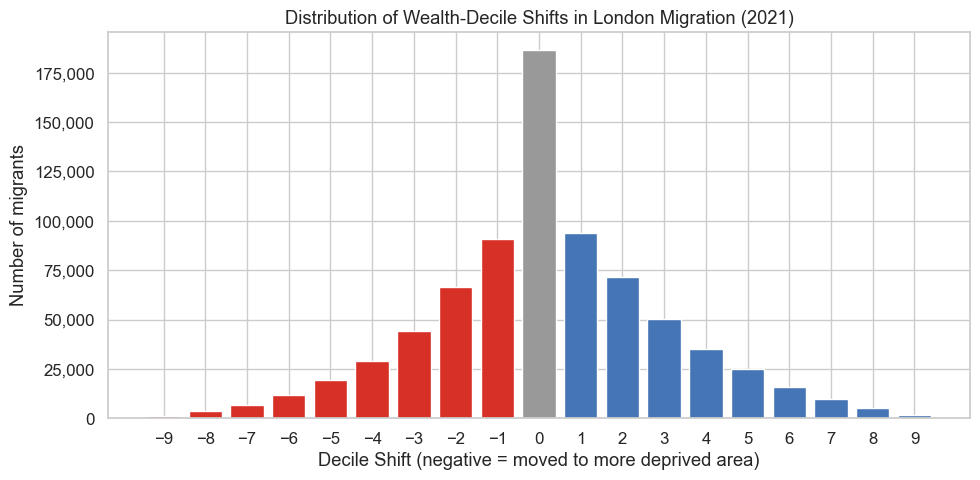

In [52]:
# Decile shift distribution
shift_dist = london_flow.groupby('Decile_Shift')[COUNT_COL].sum()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027' if x < 0 else '#4575b4' if x > 0 else '#999999' for x in shift_dist.index]
ax.bar(shift_dist.index, shift_dist.values, color=colors, edgecolor='white')
ax.set_xlabel('Decile Shift (negative = moved to more deprived area)')
ax.set_ylabel('Number of migrants')
ax.set_title('Distribution of Wealth-Decile Shifts in London Migration (2021)')
ax.set_xticks(range(shift_dist.index.min(), shift_dist.index.max() + 1))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_decile_shift.png', dpi=150, bbox_inches='tight')
plt.show()

##### NOTE:

This is the magnitude of flows:

- Upward moves outnumber downward moves at nearly every magnitude
    - consistent with the 40.2% vs 35.5% overall split

- Next, need to know if downward moves are spatially concentrated in MSOAs, that simultaneously received affluent inflows

---
## 8. Per-MSOA Cascade Features

For each MSOA:
- **Inflow from wealthier**: migrants arriving from higher wealth deciles
- **Outflow to poorer**: migrants leaving to lower wealth deciles
- **Net Cascade**: inflow_wealthier − outflow_poorer
- **Cascade Ratio**: inflow_wealthier / outflow_poorer (>1 = gentrification pressure)

In [53]:
msoa_analysis = msoa_wealth[['msoa11cd', 'ladnm', 'Wealth_Decile',
                              'IMD_2010', 'IMD_2019', 'IMD_Change']].copy()

# Inflow from wealthier areas (origin decile > dest decile)
inflow_w = (
    london_flow[london_flow['Origin_Decile'] > london_flow['Dest_Decile']]
    .groupby('dest_msoa11')[COUNT_COL].sum()
    .rename('Inflow_Wealthier')
)

# Outflow to more deprived areas (dest decile < origin decile)
outflow_p = (
    london_flow[london_flow['Dest_Decile'] < london_flow['Origin_Decile']]
    .groupby('origin_msoa11')[COUNT_COL].sum()
    .rename('Outflow_Poorer')
)

# Total inflow & outflow
total_in = london_flow.groupby('dest_msoa11')[COUNT_COL].sum().rename('Total_Inflow')
total_out = london_flow.groupby('origin_msoa11')[COUNT_COL].sum().rename('Total_Outflow')

# Merge
for s in [inflow_w, outflow_p, total_in, total_out]:
    msoa_analysis = msoa_analysis.merge(s, left_on='msoa11cd', right_index=True, how='left')

msoa_analysis = msoa_analysis.fillna(0)

# Derived features
msoa_analysis['Net_Cascade'] = msoa_analysis['Inflow_Wealthier'] - msoa_analysis['Outflow_Poorer']
msoa_analysis['Cascade_Ratio'] = np.where(
    msoa_analysis['Outflow_Poorer'] > 0,
    msoa_analysis['Inflow_Wealthier'] / msoa_analysis['Outflow_Poorer'],
    np.nan
)
msoa_analysis['Pct_Inflow_Wealthier'] = (
    msoa_analysis['Inflow_Wealthier'] / msoa_analysis['Total_Inflow'].replace(0, np.nan) * 100
)

print(f'MSOAs with flow data: {(msoa_analysis["Total_Inflow"] > 0).sum()}')
msoa_analysis.describe().round(1)

MSOAs with flow data: 963


,Wealth_Decile,IMD_2010,IMD_2019,IMD_Change,Inflow_Wealthier,Outflow_Poorer,Total_Inflow,Total_Outflow,Net_Cascade,Cascade_Ratio,Pct_Inflow_Wealthier
count,983.0,983.0,983.0,983.0,983.0,983.0,983.0,983.0,983.0,867.0,963.0
mean,5.5,25.5,21.6,-3.9,277.1,277.1,779.8,779.8,0.0,1.9,33.9
std,2.9,12.0,9.5,4.6,236.5,215.2,347.3,377.7,355.7,7.3,23.1
min,1.0,4.1,4.1,-30.5,0.0,0.0,0.0,0.0,-1058.0,0.0,0.0
25%,3.0,15.6,13.7,-6.3,89.5,128.0,535.5,499.0,-235.0,0.2,15.6
50%,6.0,24.0,21.2,-2.8,229.0,242.0,713.0,741.0,-30.0,0.7,32.1
75%,8.0,34.4,28.7,-0.6,413.0,386.0,964.5,1015.5,224.5,1.7,52.5
max,10.0,56.7,50.4,9.4,1340.0,1326.0,2366.0,2575.0,1340.0,189.0,93.1


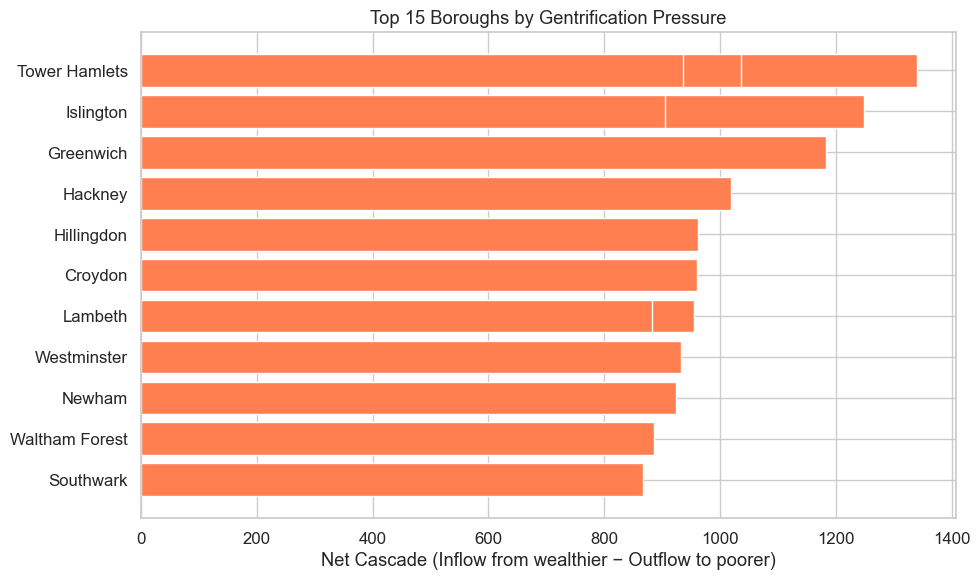

In [54]:
# Top 15 MSOAs by Net Cascade
top = msoa_analysis.nlargest(15, 'Net_Cascade')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top['ladnm'],
    top['Net_Cascade'], color='coral', edgecolor='white'
)
ax.set_xlabel('Net Cascade (Inflow from wealthier − Outflow to poorer)')
ax.set_title('Top 15 Boroughs by Gentrification Pressure')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_top_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

##### NOTE

- The strongest gentrification pressure is in Tower Hamlets, Islington, Greenwich, and Hackney.
    - They are widely recognised as gentrifying in the literature
    - These implies good validity for the index

In [55]:
# Cascade patterns by wealth decile
decile_summary = msoa_analysis.groupby('Wealth_Decile').agg(
    MSOA_Count=('msoa11cd', 'count'),
    Avg_Inflow_Wealthier=('Inflow_Wealthier', 'mean'),
    Avg_Outflow_Poorer=('Outflow_Poorer', 'mean'),
    Avg_Net_Cascade=('Net_Cascade', 'mean'),
    Avg_IMD_Change=('IMD_Change', 'mean'),
).round(1)

# Add cascade ratio (only for Decile 2-9)
decile_summary['Avg_Cascade_Ratio'] = msoa_analysis.groupby('Wealth_Decile')['Cascade_Ratio'].mean().round(2)

print('=== Average Features by Wealth Decile ===')
display(decile_summary)

=== Average Features by Wealth Decile ===


,MSOA_Count,Avg_Inflow_Wealthier,Avg_Outflow_Poorer,Avg_Net_Cascade,Avg_IMD_Change,Avg_Cascade_Ratio
Wealth_Decile,,,,,,
1,99,548.0,0.0,548.0,-11.5,NaN
2,98,460.7,165.8,294.9,-7.3,7.96
3,98,409.4,231.8,177.6,-5.3,3.17
4,98,340.9,279.8,61.1,-4.3,2.25
5,98,332.2,295.3,36.9,-3.4,1.73
6,99,258.8,374.8,-116.0,-2.7,0.95
7,98,191.4,367.6,-176.3,-1.8,0.71
8,98,146.3,379.4,-233.1,-1.8,0.59
9,98,83.7,384.4,-300.7,-0.9,0.32


In [56]:
# Test monochronicity of IMD changes and cascade pressure decreases
r, p = stats.spearmanr(decile_summary.index, decile_summary['Avg_Net_Cascade'])
print(f'Wealth Decile vs Net Cascade:  rho = {r:+.3f}, p = {p:.6f}')

r, p = stats.spearmanr(decile_summary['Avg_Net_Cascade'], decile_summary['Avg_IMD_Change'])
print(f'Net Cascade vs IMD Change:     rho = {r:+.3f}, p = {p:.6f}')

Wealth Decile vs Net Cascade:  rho = -0.988, p = 0.000000
Net Cascade vs IMD Change:     rho = -0.985, p = 0.000000


##### NOTE:

- Around decile 5-6, the `Avg_Net_Cascade` flips from postive to negative (crossover point)
    - MSOAs in deciles 1-5 are net receivers of wealthier inflows
    - MSOAs in deciles 6-10 are net senders where residents move to poorer areas

- The `Avg_Cascade_Ratio` drops monotonically from 7.96 (decile 2) down to 0.32 (decile 9)
    - Intense displacement:
        - Decile 2: for every person leaving to a poorer area, roughly 8 people arrive from wealthier areas

    - Balanced displacement:
        - Decile 6: almost 1:1 replacement
        - Decile 6 can be the "tipping line" between areas experiencing gentrification pressure and areas supplying the gentrifiers
        - critical threshold of 1.0 between decile 5 and 6 (same crossover point with Net Cascade)




- A Spearman rho close to -1.0 with p < 0.05 across deciles shows strong evidence of a monotonic relationship.
    - cascade pressure decreases
    - IMD changes

> Question: which metric (net_cascade or cascade_ratio) is better for index?

---
## 9. Validation: Cascade Index vs IMD Change

**Key test**: MSOAs with high cascade pressure should independently show falling IMD scores (becoming less deprived) between 2010 and 2019.

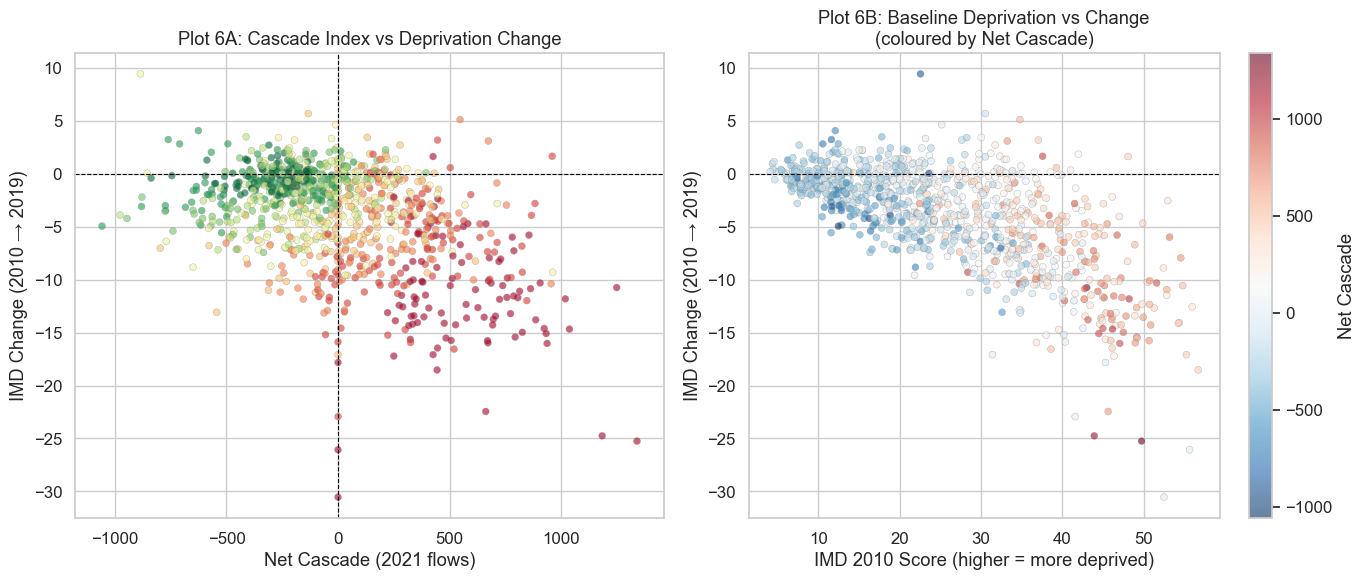

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: Net Cascade vs IMD Change
ax = axes[0]
sc = ax.scatter(
    msoa_analysis['Net_Cascade'], msoa_analysis['IMD_Change'],
    c=msoa_analysis['Wealth_Decile'], cmap='RdYlGn',
    s=25, alpha=0.6, edgecolors='grey', linewidth=0.3
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Net Cascade (2021 flows)')
ax.set_ylabel('IMD Change (2010 → 2019)')
ax.set_title('Plot 6A: Cascade Index vs Deprivation Change')

# Scatter: IMD baseline vs IMD Change, coloured by cascade
ax = axes[1]
sc2 = ax.scatter(
    msoa_analysis['IMD_2010'], msoa_analysis['IMD_Change'],
    c=msoa_analysis['Net_Cascade'], cmap='RdBu_r',
    s=25, alpha=0.6, edgecolors='grey', linewidth=0.3
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('IMD 2010 Score (higher = more deprived)')
ax.set_ylabel('IMD Change (2010 → 2019)')
ax.set_title('Plot 6B: Baseline Deprivation vs Change\n(coloured by Net Cascade)')
plt.colorbar(sc2, label='Net Cascade', ax=ax)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_validation.png', dpi=150, bbox_inches='tight')
plt.show()

##### NOTE

Plot 6A:
- __Gentrification zone__ (bottom right [positive cascade + negative IMD change])
    - densely populated with orange/red dots 

- Top left [negative cascade + positive IMD change]
    - nearly empty
    - very few areas are both losing wealthy residents and becoming more deprived


Plot 6B:
- Red dots
    - High positive cascade are more concentrated among MSOAs that are more deprived in 2010
    - Large IMD drops 
- Blue dots
     - Negative cascade cluster at the low-IMD end with minimal change

In [58]:
# Correlation statistics
from scipy import stats

for col, label in [('Net_Cascade', 'Net Cascade'),
                    ('Cascade_Ratio', 'Cascade Ratio'),
                    ('Pct_Inflow_Wealthier', '% Inflow from Wealthier')]:
    valid = msoa_analysis[[col, 'IMD_Change']].dropna()
    r, p = stats.pearsonr(valid[col], valid['IMD_Change'])
    print(f'{label:30s} vs IMD Change:  r = {r:+.3f},  p = {p:.4f}')

Net Cascade                    vs IMD Change:  r = -0.423,  p = 0.0000
Cascade Ratio                  vs IMD Change:  r = -0.051,  p = 0.1304
% Inflow from Wealthier        vs IMD Change:  r = -0.440,  p = 0.0000


##### NOTE

- Net Cascade vs IMD Change (r = -0.423) shows a moderate-to-strong negative correlation.
    - more cascade pressure goes with bigger deprivation drops

- Cascade ratio is not significant. 
    - ratio is not stable with very low outflows
    - absolute volume of cascade flows matters more than ratios to predic changes!

---
## 10. Borough-Level Summary

In [59]:
borough_summary = msoa_analysis.groupby('ladnm').agg(
    Num_MSOAs=('msoa11cd', 'count'),
    Avg_IMD_2010=('IMD_2010', 'mean'),
    Avg_IMD_Change=('IMD_Change', 'mean'),
    Total_Net_Cascade=('Net_Cascade', 'sum'),
    Avg_Cascade_Ratio=('Cascade_Ratio', 'mean'),
    Total_Inflow=('Total_Inflow', 'sum'),
    Total_Outflow=('Total_Outflow', 'sum')
).round(2).sort_values('Total_Net_Cascade', ascending=False)

display(borough_summary)

,Num_MSOAs,Avg_IMD_2010,Avg_IMD_Change,Total_Net_Cascade,Avg_Cascade_Ratio,Total_Inflow,Total_Outflow
ladnm,,,,,,,
Tower Hamlets,32,39.96,-11.57,9018.0,0.89,37678.0,38591.0
Hackney,28,43.04,-10.02,6945.0,1.06,24491.0,25975.0
Lambeth,35,31.06,-5.25,5284.0,4.07,39688.0,43084.0
Newham,37,42.43,-12.62,5010.0,0.72,24420.0,29981.0
Islington,23,35.98,-8.29,4941.0,1.79,28688.0,29705.0
Haringey,36,35.83,-8.26,3105.0,0.86,27316.0,29974.0
Greenwich,33,31.96,-8.04,3014.0,1.37,19225.0,18755.0
Brent,34,30.21,-5.02,3011.0,1.34,29173.0,33161.0
Hammersmith and Fulham,25,27.29,-4.93,2814.0,2.10,25093.0,25684.0


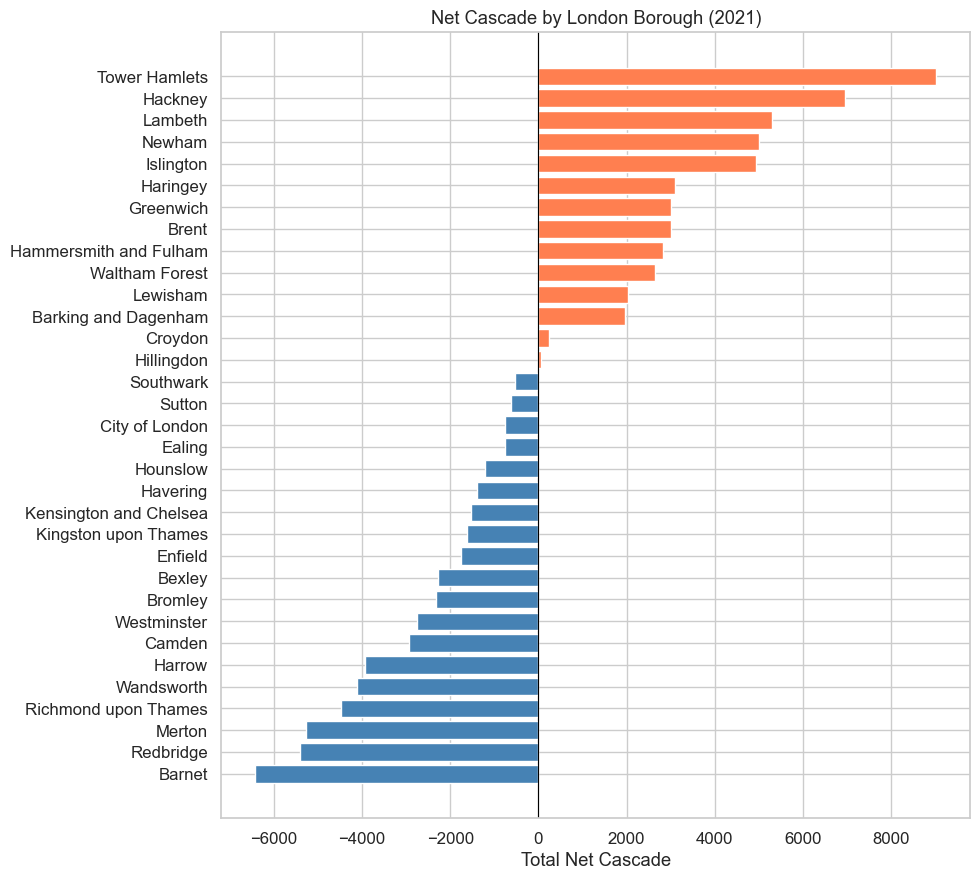

In [60]:
fig, ax = plt.subplots(figsize=(10, 9))
colors = ['coral' if v > 0 else 'steelblue' for v in borough_summary['Total_Net_Cascade']]
ax.barh(borough_summary.index, borough_summary['Total_Net_Cascade'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Total Net Cascade')
ax.set_title('Net Cascade by London Borough (2021)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_borough_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

##### NOTE

- Align with literature review
    - The top cascade boroughs are all historically deprived inner-London areas that have experienced well-documented gentrification
        - Tower Hamlets, Hackney, Lambeth, Newham, Islington
    -  The negative cascade boroughs are wealthier outer-London suburbs
        - Barnet, Redbridge, Merton, Richmond

- Outer boroughs may be receiving displaced residents from the gentrifying inner boroughs

---
## 11. Export

In [61]:
msoa_analysis.to_csv(OUTPUT_DIR / 'msoa_cascade_features.csv', index=False)
borough_summary.to_csv(OUTPUT_DIR / 'borough_summary.csv')
flow_matrix.to_csv(OUTPUT_DIR / 'flow_matrix_decile.csv')

print('Exported to outputs/:')
print('  - msoa_cascade_features.csv')
print('  - borough_summary.csv')
print('  - flow_matrix_decile.csv')

Exported to outputs/:
  - msoa_cascade_features.csv
  - borough_summary.csv
  - flow_matrix_decile.csv


---
## Discussion

1. **Option C methodology**: Fixed 2010 IMD baseline for cascade classification,
   with IMD change (2010→2019) as independent validation.

2. **2011 O-D data limitation**: MSOA-level residential migration from the 2011
   Census is safeguarded (not publicly downloadable). Options: apply for WICID
   access, or use LA-level 2011 data as a supplementary analysis.

3. **Cascade Index formalisation**: Current metric is
   `Net_Cascade = Inflow_from_wealthier − Outflow_to_poorer`.
   Should we normalise by total flow volume? Weight by decile shift magnitude?

4. **COVID caveat**: The 2021 Census (21 March 2021) was during COVID restrictions.
   Migration patterns in the preceding year may be atypical.

5. **Geography**: ~2.5% of MSOAs nationally changed between 2011 and 2021.
   We excluded these. How many are in London, and does it matter?

6. **Next steps**: Alluvial plots, spatial mapping with geopandas,
   and potentially ODMG04EW (migration by NS-SEC) for individual-level
   socio-economic classification rather than area-based IMD proxy.